In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 1: Data Inspection & Structural Audit

In [ ]:
df = pd.read_csv('train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
df[num_cols].isna().sum()

,0
Id,0
MSSubClass,0
LotFrontage,259
LotArea,0
OverallQual,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
MasVnrArea,8
BsmtFinSF1,0


In [ ]:
df[cat_cols].isna().sum()

,0
MSZoning,0
Street,0
Alley,1369
LotShape,0
LandContour,0
Utilities,0
LotConfig,0
LandSlope,0
Neighborhood,0
Condition1,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
target = 'SalePrice'

df[target]

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [ ]:
df[target].isna().sum()

np.int64(0)

In [ ]:
sale_price_mean = df['SalePrice'].mean()
sale_price_median = df['SalePrice'].median()
sale_price_skew = df['SalePrice'].skew()
sale_price_kurt = df['SalePrice'].kurt()

print(f"Mean of SalePrice: {sale_price_mean:.2f}")
print(f"Median of SalePrice: {sale_price_median:.2f}")
print(f"Skewness of SalePrice: {sale_price_skew:.2f}")
print(f"Kurtosis of SalePrice: {sale_price_kurt:.2f}")

Mean of SalePrice: 180921.20
Median of SalePrice: 163000.00
Skewness of SalePrice: 1.88
Kurtosis of SalePrice: 6.54


Skewness (1.88): Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean. A value of 1.88 indicates a positive skew (also known as right-skewness). This means that the tail on the right side of the distribution is longer or fatter than the left side. In simpler terms, there are more sales with lower prices, and fewer sales with very high prices, pulling the average higher than the median. A perfectly symmetrical distribution would have a skewness of 0.

Kurtosis (6.54): Kurtosis measures the 'tailedness' of the probability distribution. It describes how heavily the tails of a distribution differ from the tails of a normal distribution. A normal distribution has a kurtosis of 3 (or 0, if using excess kurtosis which is more common in statistical software). A value of 6.54 (which is significantly greater than 3, or greater than 0 for excess kurtosis) indicates that your 'SalePrice' distribution is leptokurtic. This means it has fatter tails and a sharper peak compared to a normal distribution. In practical terms, this suggests that there are more extreme values (both very low and very high sale prices) than you would expect in a normal distribution, and also a more concentrated cluster of values around the mean.

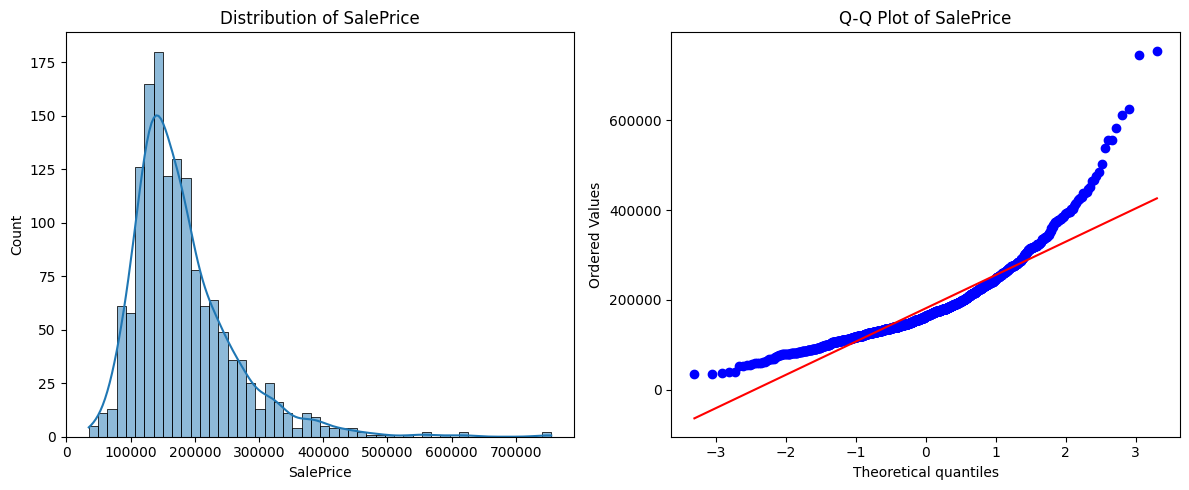

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], bins=50, kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')

# Q-Q Plot of SalePrice
plt.subplot(1, 2, 2)
stats.probplot(df['SalePrice'], dist="norm", plot=plt)
plt.title('Q-Q Plot of SalePrice')

plt.tight_layout()
plt.show()

In [ ]:
df['SalePrice_Log'] = np.log1p(df['SalePrice'])
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_Log
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,12.429220


**Reasoning**:
Now that 'SalePrice' has been log-transformed, I will recalculate its mean, median, skewness, and kurtosis using the 'SalePrice_Log' column to evaluate the effect of the transformation.



In [ ]:
sale_price_log_mean = df['SalePrice_Log'].mean()
sale_price_log_median = df['SalePrice_Log'].median()
sale_price_log_skew = df['SalePrice_Log'].skew()
sale_price_log_kurt = df['SalePrice_Log'].kurt()

print(f"Mean of Log-transformed SalePrice: {sale_price_log_mean:.2f}")
print(f"Median of Log-transformed SalePrice: {sale_price_log_median:.2f}")
print(f"Skewness of Log-transformed SalePrice: {sale_price_log_skew:.2f}")
print(f"Kurtosis of Log-transformed SalePrice: {sale_price_log_kurt:.2f}")

Mean of Log-transformed SalePrice: 12.02
Median of Log-transformed SalePrice: 12.00
Skewness of Log-transformed SalePrice: 0.12
Kurtosis of Log-transformed SalePrice: 0.81


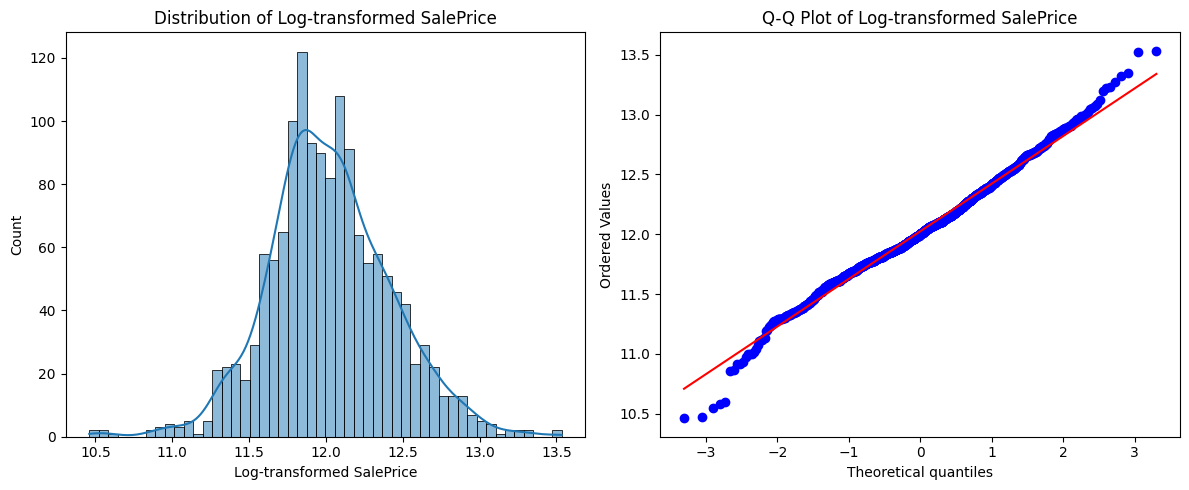

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice_Log'], bins=50, kde=True)
plt.title('Distribution of Log-transformed SalePrice')
plt.xlabel('Log-transformed SalePrice')

plt.subplot(1, 2, 2)
stats.probplot(df['SalePrice_Log'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Log-transformed SalePrice')

plt.tight_layout()
plt.show()

# Phase 2: The "Cleaning" Ritual

In [ ]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"First Quartile (Q1): {Q1:.2f}")
print(f"Third Quartile (Q3): {Q3:.2f}")
print(f"Interquartile Range (IQR): {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

First Quartile (Q1): 129975.00
Third Quartile (Q3): 214000.00
Interquartile Range (IQR): 84025.00
Lower Bound for Outliers: 3937.50
Upper Bound for Outliers: 340037.50


In [ ]:
df_filtered = df[(df['SalePrice'] >= lower_bound) & (df['SalePrice'] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (after outlier removal): {df_filtered.shape}")

Original DataFrame shape: (1460, 82)
Filtered DataFrame shape (after outlier removal): (1399, 82)


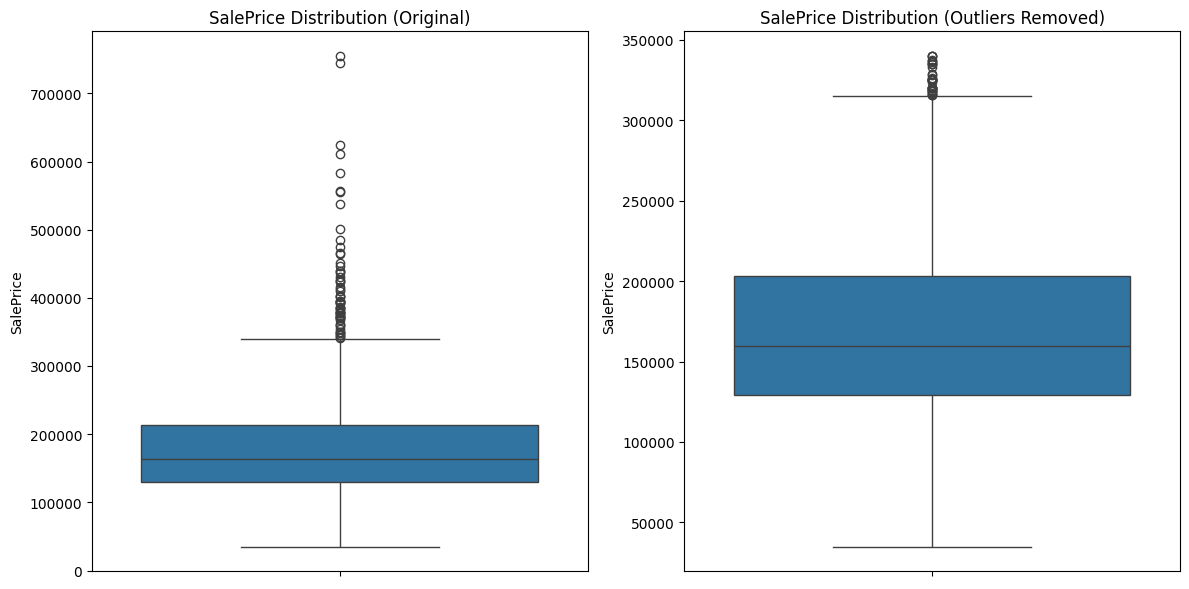

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['SalePrice'])
plt.title('SalePrice Distribution (Original)')
plt.ylabel('SalePrice')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_filtered['SalePrice'])
plt.title('SalePrice Distribution (Outliers Removed)')
plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()

# Phase 3: Multivariate Analysis & Visualization

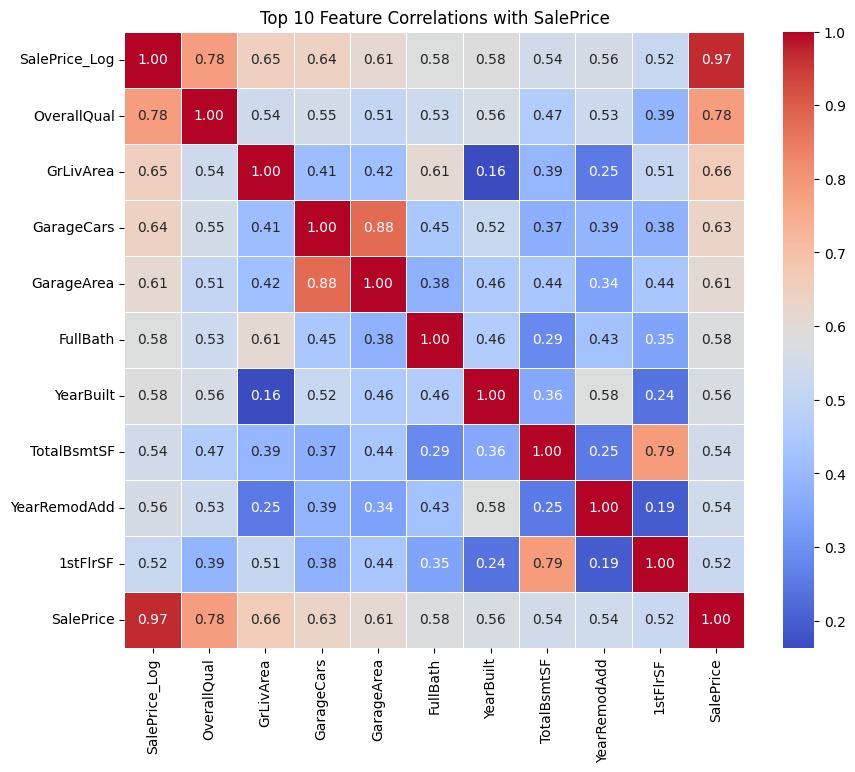

In [ ]:
numerical_cols_filtered = df_filtered.select_dtypes(include=np.number).columns
numerical_cols_filtered = numerical_cols_filtered.drop('Id')

correlation_matrix = df_filtered[numerical_cols_filtered].corr()

saleprice_correlations = correlation_matrix['SalePrice'].sort_values(ascending=False)

top_10_correlated_features = saleprice_correlations.drop('SalePrice').abs().sort_values(ascending=False).head(10).index.tolist()

df_top_10 = df_filtered[top_10_correlated_features + ['SalePrice']]

correlation_matrix_top_10 = df_top_10.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_top_10, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Top 10 Feature Correlations with SalePrice')
plt.show()

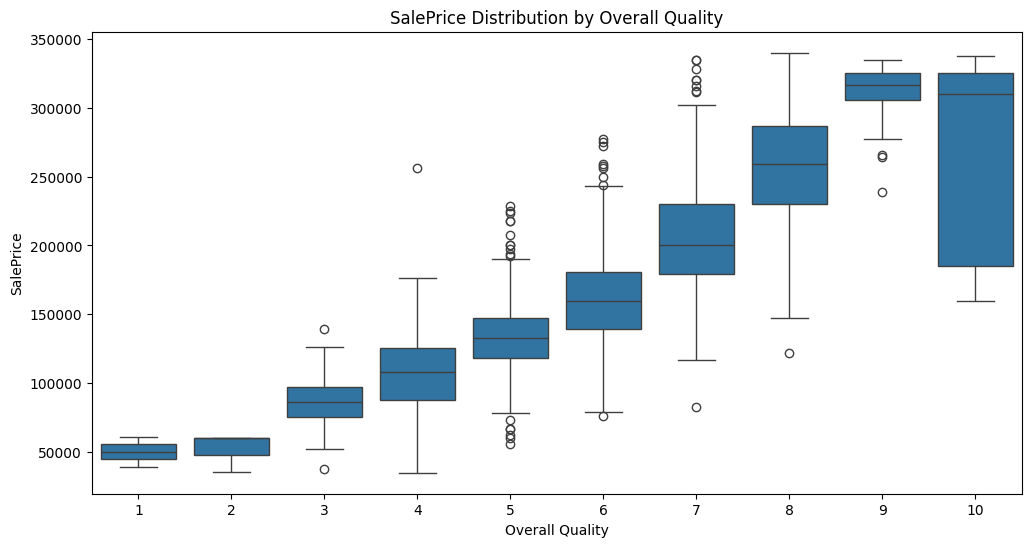

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_filtered)
plt.xlabel('Overall Quality')
plt.ylabel('SalePrice')
plt.title('SalePrice Distribution by Overall Quality')
plt.show()

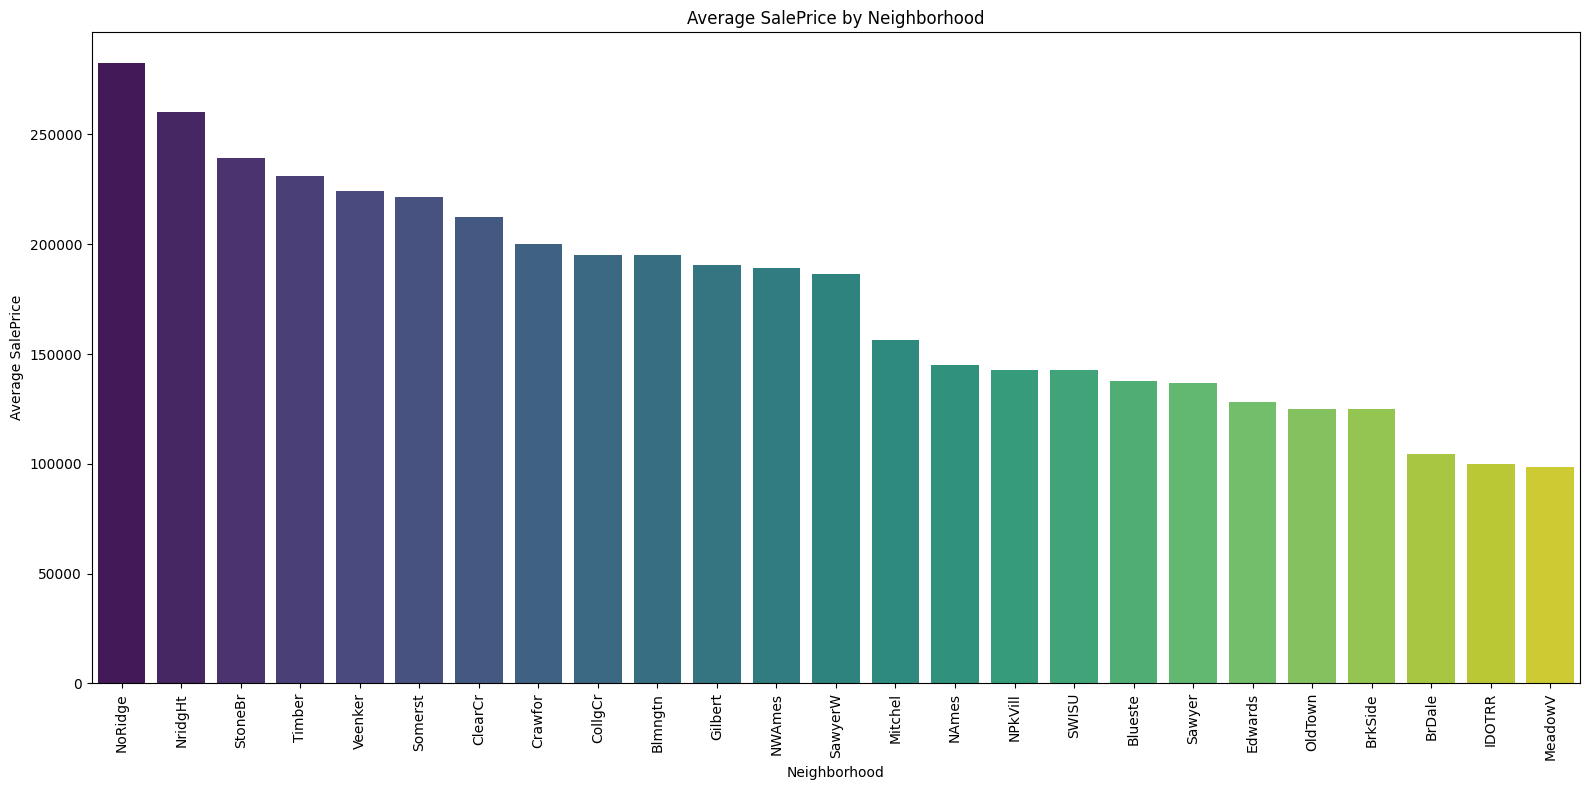

The neighborhood with the highest average SalePrice is: NoRidge (Average Price: $282,386.93)


In [ ]:
neighborhood_avg_price = df_filtered.groupby('Neighborhood')['SalePrice'].mean()

neighborhood_avg_price_sorted = neighborhood_avg_price.sort_values(ascending=False)

plt.figure(figsize=(16, 8))
sns.barplot(x=neighborhood_avg_price_sorted.index, y=neighborhood_avg_price_sorted.values, hue=neighborhood_avg_price_sorted.index, palette='viridis', legend=False)

plt.xticks(rotation=90)

plt.xlabel('Neighborhood')
plt.ylabel('Average SalePrice')
plt.title('Average SalePrice by Neighborhood')

plt.tight_layout()
plt.show()

highest_avg_price_neighborhood = neighborhood_avg_price_sorted.index[0]
highest_avg_price_value = neighborhood_avg_price_sorted.values[0]

print(f"The neighborhood with the highest average SalePrice is: {highest_avg_price_neighborhood} (Average Price: ${highest_avg_price_value:,.2f})")

# Phase 4: Final Insights & Reporting

In [ ]:
top_3_features = top_10_correlated_features[:3]
print("Top 3 features most correlated with SalePrice:")
for feature in top_3_features:
    print(f"- {feature}: {saleprice_correlations[feature]:.2f}")

Top 3 features most correlated with SalePrice:
- SalePrice_Log: 0.97
- OverallQual: 0.78
- GrLivArea: 0.66


## Anamoly Report

### Features with Most Missing Data and Their Potential Impact:

Based on the data inspection, several features have a significant number of missing values. It's crucial to understand the nature of these missing values, as they might represent the absence of a feature rather than actual missing data points, which can be valuable information for a predictive model.

1.  **PoolQC (Pool Quality)**: 1453 missing values out of 1460 (approx. 99.5% missing).
    *   **Potential Impact**: The high number of missing values indicates that most houses do not have a pool. This is a common scenario where `NaN` or `None` actually means 'no pool'. For a predictive model, it's highly likely that houses without a pool will have a different (likely lower) `SalePrice` compared to houses with a pool. Treating `NaN` as 'No Pool' (a new category) would be more appropriate than imputation, as this information is significant.

2.  **MiscFeature (Miscellaneous Feature)**: 1406 missing values out of 1460 (approx. 96.3% missing).
    *   **Potential Impact**: Similar to `PoolQC`, missing values here likely indicate the absence of miscellaneous features (e.g., tennis court, shed). This information is highly informative. Imputing with 'None' or 'No MiscFeature' would be beneficial, as the presence of such a feature would likely impact `SalePrice`.

3.  **Alley (Type of alley access)**: 1369 missing values out of 1460 (approx. 93.8% missing).
    *   **Potential Impact**: The majority of properties do not have alley access. This `NaN` implies 'no alley access'. This categorical information can be very useful for the model, distinguishing properties with and without alley access. Filling `NaN` with 'No Alley' is a suitable strategy.

4.  **Fence (Fence Quality)**: 1179 missing values out of 1460 (approx. 80.8% missing).
    *   **Potential Impact**: Most houses do not have a fence, or their fence quality is not specified. Again, `NaN` signifies 'no fence'. The presence or absence of a fence, and its quality, can influence property value. Replacing `NaN` with 'No Fence' will capture this valuable distinction.

5.  **MasVnrType (Masonry Veneer Type)**: 872 missing values out of 1460 (approx. 59.7% missing).
    *   **Potential Impact**: A significant portion of homes lack a masonry veneer. This suggests that `NaN` here implies 'no masonry veneer'. The type and presence of masonry veneer can affect a home's aesthetic appeal and perceived value. Treating `NaN` as a distinct category ('None') is a good approach.

6.  **FireplaceQu (Fireplace Quality)**: 690 missing values out of 1460 (approx. 47.3% missing).
    *   **Potential Impact**: Nearly half of the homes do not have a fireplace, indicated by `NaN`. The presence and quality of a fireplace can be a desirable feature impacting `SalePrice`. Converting `NaN` to 'No Fireplace' would effectively leverage this information.


The following four charts have been identified as most impactful for the managerial report. These charts were already generated in previous steps. For the final report, refer to these visualizations:

1.  **Distribution of Log-transformed SalePrice**: This chart illustrates the normalized distribution of the target variable after log transformation, which is crucial for meeting assumptions of many regression models. (Refer to the output of the cell where `sns.histplot(df['SalePrice_Log'], bins=50, kde=True)` was executed).
2.  **SalePrice Distribution after Outlier Removal**: This chart visually confirms the effect of outlier removal on the `SalePrice` distribution, showing a more refined and less skewed dataset. (Refer to the output of the cell containing the box plots of original and filtered `SalePrice`).
3.  **Top 10 Feature Correlations with SalePrice**: This heatmap provides a clear overview of the strongest linear relationships between numerical features and `SalePrice`, highlighting key drivers of housing prices. (Refer to the output of the cell where `sns.heatmap(correlation_matrix_top_10, annot=True, cmap='coolwarm')` was executed).
4.  **Average SalePrice by Neighborhood**: This bar chart offers valuable geographical insights, identifying neighborhoods with higher average sale prices, which is important for strategic decision-making. (Refer to the output of the cell where `sns.barplot(x=neighborhood_avg_price_sorted.index, y=neighborhood_avg_price_sorted.values)` was executed).